In [1]:
import pandas as pd

df = pd.read_csv(r"C:\Users\PC-LOQ\Desktop\internship\day7(SPAM_EMAIL_DETECTION)\dataset\spam.csv")

print(df.head())
print(df.shape)
print(df.columns)

  Category                                            Message
0      ham  Go until jurong point, crazy.. Available only ...
1      ham                      Ok lar... Joking wif u oni...
2     spam  Free entry in 2 a wkly comp to win FA Cup fina...
3      ham  U dun say so early hor... U c already then say...
4      ham  Nah I don't think he goes to usf, he lives aro...
(5572, 2)
Index(['Category', 'Message'], dtype='object')


In [2]:
print(df.isnull().sum())
print(df["Category"].value_counts())

Category    0
Message     0
dtype: int64
Category
ham     4825
spam     747
Name: count, dtype: int64


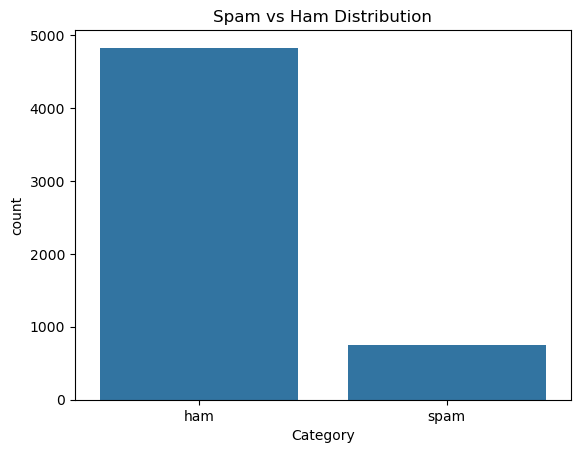

In [3]:
import seaborn as sns
import matplotlib.pyplot as plt

sns.countplot(x="Category",data=df)
plt.title("Spam vs Ham Distribution")

plt.show()

In [4]:
df["Category"] = df["Category"].map({
    "ham":0,
    "spam":1
})

print(df.head())

   Category                                            Message
0         0  Go until jurong point, crazy.. Available only ...
1         0                      Ok lar... Joking wif u oni...
2         1  Free entry in 2 a wkly comp to win FA Cup fina...
3         0  U dun say so early hor... U c already then say...
4         0  Nah I don't think he goes to usf, he lives aro...


In [5]:
X = df["Message"]

y = df["Category"]

In [6]:
from sklearn.feature_extraction.text import TfidfVectorizer

vectorizer = TfidfVectorizer(
    stop_words="english"
)

X = vectorizer.fit_transform(X)

In [7]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42
)

In [8]:
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score

lr = LogisticRegression()

lr.fit(X_train, y_train)

pred_lr = lr.predict(X_test)

acc_lr = accuracy_score(
    y_test,
    pred_lr
)

print("Logistic Accuracy =", acc_lr)

Logistic Accuracy = 0.95695067264574


In [9]:
from sklearn.neighbors import KNeighborsClassifier

knn = KNeighborsClassifier()

knn.fit(X_train, y_train)

pred_knn = knn.predict(X_test)

acc_knn = accuracy_score(
    y_test,
    pred_knn
)

print("KNN Accuracy =", acc_knn)

KNN Accuracy = 0.9103139013452914


In [10]:
from sklearn.ensemble import RandomForestClassifier

rf = RandomForestClassifier(
    n_estimators=100,
    random_state=42
)

rf.fit(X_train, y_train)

pred_rf = rf.predict(X_test)

acc_rf = accuracy_score(
    y_test,
    pred_rf
)

print("Random Forest Accuracy =", acc_rf)

Random Forest Accuracy = 0.9811659192825112


In [11]:
from sklearn.ensemble import AdaBoostClassifier

ab = AdaBoostClassifier(
    random_state=42
)

ab.fit(X_train, y_train)

pred_ab = ab.predict(X_test)

acc_ab = accuracy_score(
    y_test,
    pred_ab
)

print("AdaBoost Accuracy =", acc_ab)

AdaBoost Accuracy = 0.9076233183856502


In [12]:
results = pd.DataFrame({

    "Model":[
        "Logistic Regression",
        "KNN",
        "Random Forest",
        "AdaBoost"
    ],

    "Accuracy":[
        acc_lr,
        acc_knn,
        acc_rf,
        acc_ab
    ]
})

print(results)

                 Model  Accuracy
0  Logistic Regression  0.956951
1                  KNN  0.910314
2        Random Forest  0.981166
3             AdaBoost  0.907623


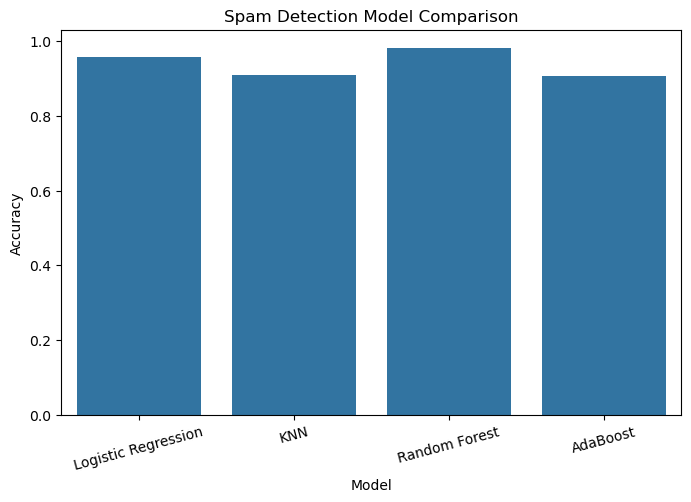

In [13]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(8,5))

sns.barplot(
    x="Model",
    y="Accuracy",
    data=results
)

plt.title("Spam Detection Model Comparison")

plt.xticks(rotation=15)

plt.show()

In [14]:
from sklearn.metrics import confusion_matrix

cm = confusion_matrix(
    y_test,
    pred_rf
)

print(cm)


[[966   0]
 [ 21 128]]


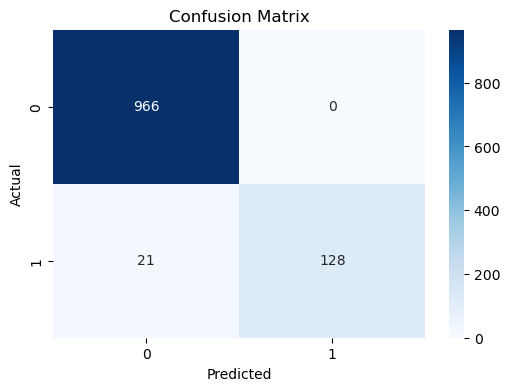

In [15]:
plt.figure(figsize=(6,4))

sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues"
)

plt.title("Confusion Matrix")

plt.xlabel("Predicted")
plt.ylabel("Actual")

plt.show()

In [16]:
from sklearn.metrics import classification_report

print(
    classification_report(
        y_test,
        pred_rf
    )
)

              precision    recall  f1-score   support

           0       0.98      1.00      0.99       966
           1       1.00      0.86      0.92       149

    accuracy                           0.98      1115
   macro avg       0.99      0.93      0.96      1115
weighted avg       0.98      0.98      0.98      1115

